# Retail Centre Makeup vs. Visit Pattern Analysis

This notebook analyzes the relationship between the physical composition (makeup) of retail centres and the simulated visits they attract in the ABM.

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Set plotting style
sns.set_theme(style="whitegrid")

In [9]:
# --- Configuration ---
RETAIL_CENTRES_GPKG = r'C:\Users\sgabalog\Documents\P3\Model\Retail Centre Data\retail_centre_type_counts.gpkg'
OUTPUT_DIR = r'C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs'

def get_latest_visits_log(output_dir):
    list_of_files = glob.glob(os.path.join(output_dir, 'visits_log_*.parquet'))
    if not list_of_files:
        return None
    latest_file = max(list_of_files, key=os.path.getctime)
    return latest_file

## 1. Load Data

In [10]:
visits_path = get_latest_visits_log(OUTPUT_DIR)
if not visits_path:
    print("Error: No visits log found.")
else:
    print(f"Loading visits from: {os.path.basename(visits_path)}")
    df_visits = pd.read_parquet(visits_path)

print(f"Loading centres from: {os.path.basename(RETAIL_CENTRES_GPKG)}")
gdf_rc = gpd.read_file(RETAIL_CENTRES_GPKG, layer='retail_centre_counts')

# Pre-processing IDs
gdf_rc['RC_ID'] = gdf_rc['RC_ID'].astype(str).apply(lambda x: x[:-2] if x.endswith('.0') else x)
df_visits['Retail_Centre'] = df_visits['Retail_Centre'].astype(str)

Loading visits from: visits_log_1776161659.parquet
Loading centres from: retail_centre_type_counts.gpkg


## 2. Calculate Composition percentages

We calculate the percentage of various amenities within each centre based on their total POI count.

In [11]:
amenity_cols = [
    'Foodstore', 'Convenience Store', 'Retail', 'Cafe', 
    'Personal Service', 'Professional Services', 'Restaurant', 'Entertainment'
]

# Filter to centres with POIs
gdf_rc = gdf_rc[gdf_rc['Total_POI_'] > 0].copy()

for col in amenity_cols:
    if col in gdf_rc.columns:
        gdf_rc[f'pct_{col}'] = (gdf_rc[col] / gdf_rc['Total_POI_']) * 100

## 3. Merge Visits with Makeup

In [12]:
# Aggregate Visits
visits_per_centre = df_visits.groupby('Retail_Centre').size().reset_index(name='total_visits')
visits_by_type = df_visits.groupby(['Retail_Centre', 'Trip_Type']).size().unstack(fill_value=0).reset_index()

# Merge
df_analysis = gdf_rc.merge(visits_per_centre, left_on='RC_ID', right_on='Retail_Centre', how='left').fillna(0)
df_analysis = df_analysis.merge(visits_by_type, left_on='RC_ID', right_on='Retail_Centre', how='left').fillna(0)

# Clean up redundant columns
cols_to_drop = [c for c in df_analysis.columns if 'Retail_Centre' in c]
df_analysis.drop(columns=cols_to_drop, inplace=True)

df_analysis.head()

C:\Users\sgabalog\AppData\Local\Temp\ipykernel_30448\92057457.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_analysis = gdf_rc.merge(visits_per_centre, left_on='RC_ID', right_on='Retail_Centre', how='left').fillna(0)


,fid_original,RC_ID,Total_POI_,H3_cells,Dining_and,Leisure_Tr,Community_,category_n,centre_typ,LocalAutho,...,pct_Personal Service,pct_Professional Services,pct_Restaurant,pct_Entertainment,total_visits,comparison,entertainment,food_drink,grocery,service
0,3545.0,6442,15.0,3.0,4.0,0.0,2.0,['Drugstore' 'Pharmacy' 'Café' 'Funeral Home' ...,centre,Knowsley,...,20.000000,6.666667,20.000000,0.00,8526.0,1130.0,0.0,1995.0,3825.0,1576.0
1,3640.0,7143,13.0,3.0,4.0,0.0,1.0,['Tanning Salon' 'Drugstore' 'Post Office' 'Fl...,centre,Knowsley,...,15.384615,0.000000,30.769231,0.00,8734.0,5535.0,0.0,1973.0,1226.0,0.0
2,3641.0,1388,112.0,76.0,19.0,3.0,7.0,"[""Doctor's Office"" 'Sporting Goods Retail' 'Be...",centre,Knowsley,...,20.535714,14.285714,7.142857,6.25,47528.0,7942.0,11827.0,5059.0,9450.0,13250.0
3,3564.0,7611,12.0,4.0,4.0,0.0,3.0,"[""Doctor's Office"" 'Café' 'Post Office' 'Gift ...",centre,Knowsley,...,8.333333,8.333333,16.666667,0.00,15075.0,3322.0,0.0,2647.0,4611.0,4495.0
4,3559.0,5054,21.0,41.0,2.0,1.0,0.0,['Hardware Store' 'Tanning Salon' 'Pharmacy' '...,centre,Liverpool,...,23.809524,0.000000,4.761905,0.00,9651.0,4281.0,0.0,1959.0,3411.0,0.0


## 4. Correlation Analysis

How strongly does a centre's makeup correlate with its visit profile?

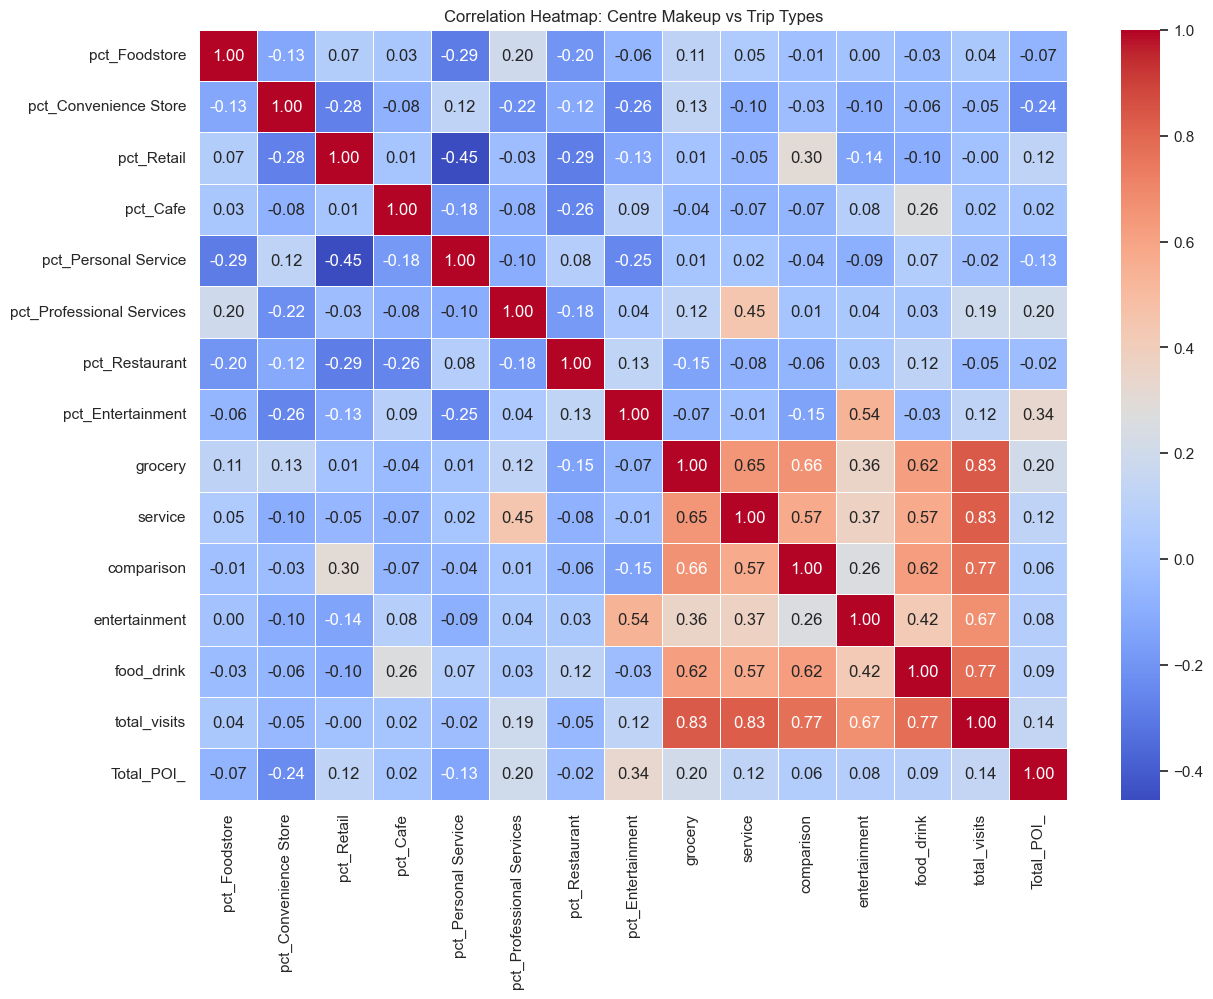

In [13]:
makeup_pct_cols = [f'pct_{c}' for c in amenity_cols if f'pct_{c}' in df_analysis.columns]
trip_type_cols = [c for c in df_visits['Trip_Type'].unique()]

corr_cols = makeup_pct_cols + trip_type_cols + ['total_visits', 'Total_POI_']
corr_matrix = df_analysis[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap: Centre Makeup vs Trip Types")
plt.show()

## 5. Visualizing Specific Relationships

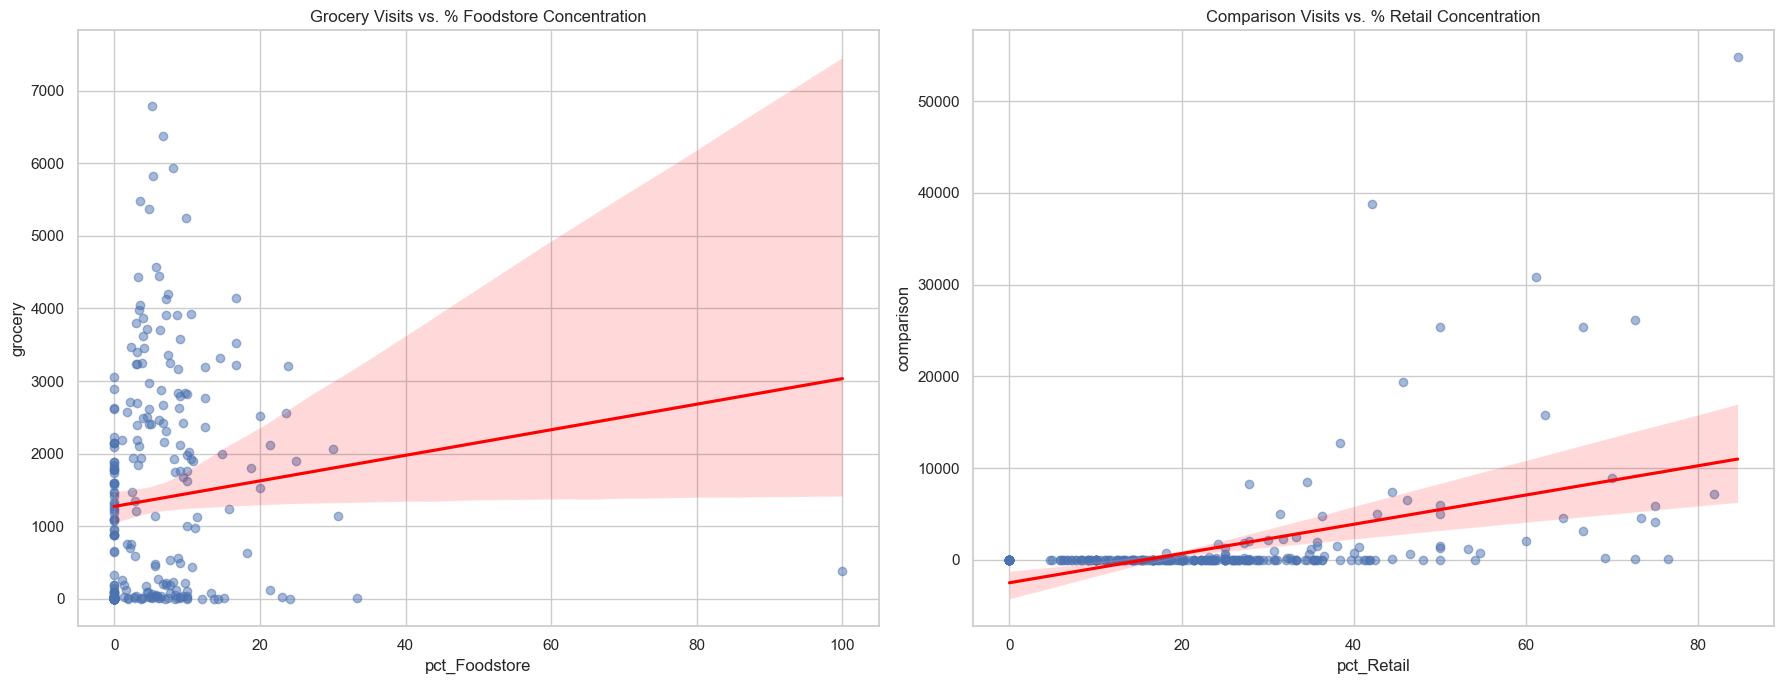

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if 'grocery' in df_analysis.columns and 'pct_Foodstore' in df_analysis.columns:
    sns.regplot(data=df_analysis, x='pct_Foodstore', y='grocery', ax=axes[0], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[0].set_title("Grocery Visits vs. % Foodstore Concentration")

if 'comparison' in df_analysis.columns and 'pct_Retail' in df_analysis.columns:
    sns.regplot(data=df_analysis, x='pct_Retail', y='comparison', ax=axes[1], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[1].set_title("Comparison Visits vs. % Retail Concentration")

plt.tight_layout()
plt.show()

## 6. Top 10 Centres Summary

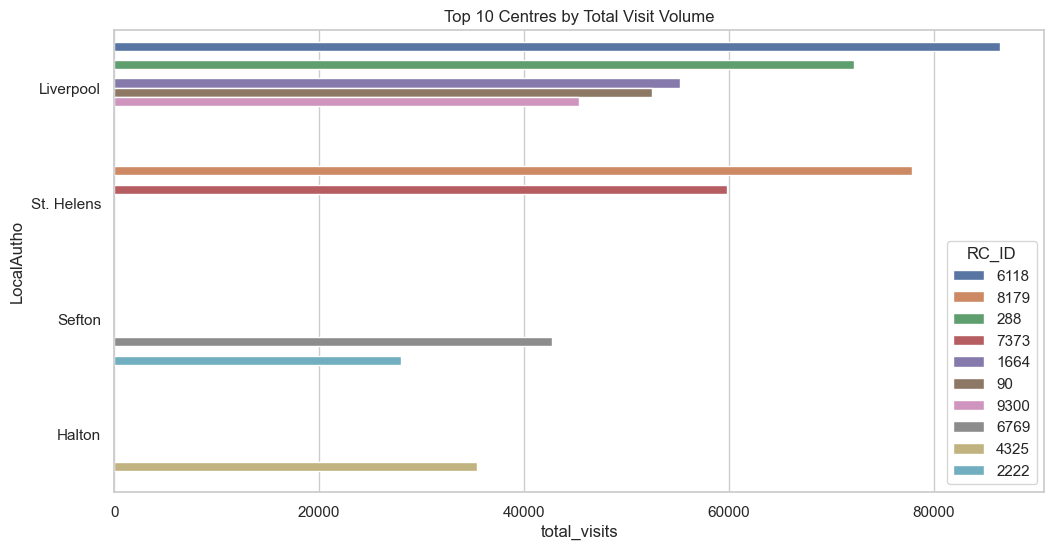

Summary Table:


,RC_ID,LocalAutho,total_visits,Total_POI_,pct_Foodstore,pct_Convenience Store,pct_Retail,pct_Cafe,pct_Personal Service,pct_Professional Services,pct_Restaurant,pct_Entertainment
32,6118,Liverpool,86440.0,16.0,6.25,6.25,6.25,12.50,25.00,43.75,12.50,0.00
114,8179,St. Helens,77872.0,11.0,0.00,0.00,0.00,0.00,9.09,9.09,36.36,45.45
256,288,Liverpool,72208.0,404.0,1.73,2.48,20.30,12.87,14.85,40.59,16.34,21.53
115,7373,St. Helens,59820.0,13.0,30.77,0.00,84.62,7.69,0.00,0.00,7.69,0.00
28,1664,Liverpool,55238.0,90.0,2.22,4.44,14.44,17.78,6.67,5.56,41.11,23.33
23,90,Liverpool,52435.0,770.0,2.34,2.34,19.74,9.22,9.22,4.94,27.53,34.94
84,9300,Liverpool,45311.0,9.0,11.11,0.00,11.11,22.22,11.11,0.00,22.22,33.33
158,6769,Sefton,42699.0,14.0,0.00,0.00,21.43,7.14,35.71,35.71,0.00,21.43
250,4325,Halton,35378.0,26.0,0.00,0.00,19.23,3.85,19.23,7.69,38.46,38.46
168,2222,Sefton,27945.0,63.0,1.59,4.76,66.67,9.52,1.59,4.76,12.70,0.00


In [8]:
top_10 = df_analysis.nlargest(10, 'total_visits')
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='total_visits', y='LocalAutho', hue='RC_ID')
plt.title("Top 10 Centres by Total Visit Volume")
plt.show()

print("Summary Table:")
top_10[['RC_ID', 'LocalAutho', 'total_visits', 'Total_POI_'] + makeup_pct_cols].round(2)